In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from carps.analysis.gather_data import read_jsonl_content
from carps.analysis.utils import savefig, setup_seaborn
from dacboenv.experiment.collect_incumbents import add_metadata_to_dict
from omegaconf import OmegaConf
from tqdm import tqdm

setup_seaborn()

log_fn = "DACBOEnvActions.jsonl"
rundirs = [
    "../runs_v1/runs_eval/PPO-MLP--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed1/BBOB/bbob/2/8",
    "../runs_v1/runs_eval/PPO-MLP--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed2/BBOB/bbob/2/8",
    "../runs_v1/runs_eval/PPO-MLP--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed3/BBOB/bbob/2/8",
    "../runs_v1/runs_eval/PPO-MLP--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed4/BBOB/bbob/2/8",
    "../runs_v1/runs_eval/PPO-MLP--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed5/BBOB/bbob/2/8",
    "../runs_v1/runs_eval_v1/PPO-MLP--dacbo_Csymlogregret_AWEI-skip_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed1/BBOB/bbob/2/8",
    "../runs_v1/runs_eval_v1/PPO-MLP--dacbo_Csymlogregret_AWEI-skip_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed2/BBOB/bbob/2/8",
    "../runs_v1/runs_eval_v1/PPO-MLP--dacbo_Csymlogregret_AWEI-skip_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed3/BBOB/bbob/2/8",
    "../runs_v1/runs_eval_v1/PPO-MLP--dacbo_Csymlogregret_AWEI-skip_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed4/BBOB/bbob/2/8",
    "../runs_v1/runs_eval_v1/PPO-MLP--dacbo_Csymlogregret_AWEI-skip_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed5/BBOB/bbob/2/8",
]
filenames = []
while rundirs:
    rundir = rundirs.pop()
    print("gather from", rundir)
    if "*" in str(rundir):
        parent_dir = Path(rundir).parent
        _rundirs = list(parent_dir.glob(Path(rundir).name))
        rundirs.extend(_rundirs)
        print(rundirs)
    _fns = list(Path(rundir).glob(f"**/{log_fn}"))
    filenames.extend(_fns)

def load_actions(filenames: list[str], add_obs: bool = False) -> pd.DataFrame:
    actions = []
    for rundir in tqdm(filenames):
        rundir = Path(rundir)
        if not rundir.exists():
            continue
        cfg_fn = rundir.parent / ".hydra/config.yaml"
        cfg = OmegaConf.load(cfg_fn)
        acts = read_jsonl_content(rundir)
        if "action_values" in acts:
            acts["action"] = acts["action_values"].map(lambda x: x[1])
        policy_id = cfg.policy_id if hasattr(cfg, "policy_id") else rundir.parts[-8]
        acts["policy_id"] = policy_id
        acts = add_metadata_to_dict(acts, cfg)
        if "config" in acts:
            del acts["config"]

        if add_obs:
            obs = read_jsonl_content(rundir.parent / "DACBOEnvLogs.jsonl")
            obs_keys = list(obs.iloc[0]["observation"].keys())

            expanded = obs["observation"].apply(pd.Series)
            expanded.columns = obs_keys
            obs = obs.drop(columns="observation").join(expanded)
            acts = acts.merge(
                obs,
                on="n_trials",
                how="left",
                # validate="many_to_one"
            )

        actions.append(acts)
    actions = pd.concat(actions).reset_index(drop=True)
    return actions

print(len(filenames))
print(filenames[-1])
actions = load_actions(filenames, add_obs=True)
actions.to_parquet("actions_skip_vs_noskip.parquet")

gather from ../runs_v1/runs_eval_v1/PPO-MLP--dacbo_Csymlogregret_AWEI-skip_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed5/BBOB/bbob/2/8
gather from ../runs_v1/runs_eval_v1/PPO-MLP--dacbo_Csymlogregret_AWEI-skip_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed4/BBOB/bbob/2/8
gather from ../runs_v1/runs_eval_v1/PPO-MLP--dacbo_Csymlogregret_AWEI-skip_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed3/BBOB/bbob/2/8
gather from ../runs_v1/runs_eval_v1/PPO-MLP--dacbo_Csymlogregret_AWEI-skip_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed2/BBOB/bbob/2/8
gather from ../runs_v1/runs_eval_v1/PPO-MLP--dacbo_Csymlogregret_AWEI-skip_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed1/BBOB/bbob/2/8
gather from ../runs_v1/runs_eval/PPO-MLP--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed5/BBOB/bbob/2/8
gather from ../runs_v1/runs_eval/PPO-MLP--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid8_3seeds--seed4/BBOB/

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 58.01it/s]


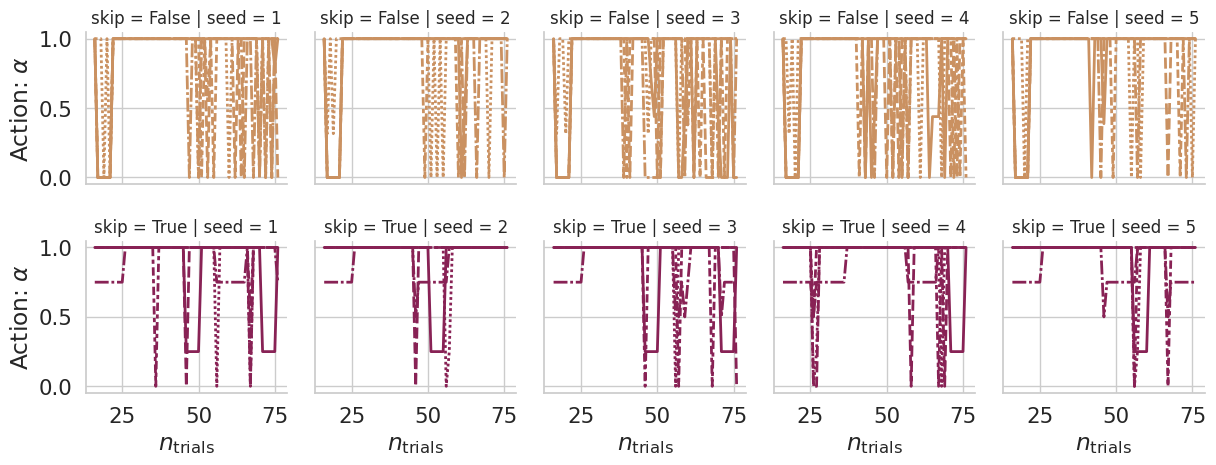

In [6]:
setup_seaborn(font_scale=1.4)

ids = actions["optimizer_id"].str.contains("skip")
actions.loc[:, "skip"] = ids
actions.loc[:, "outer_seed"] = actions["optimizer_id"].map(lambda x: int(x.split("--")[-1].replace("seed", "")))
actions_skip = actions[ids]
actions_noskip = actions[~ids]
_actions = actions[actions["seed"] < 6]

palette = {
    False: (0.792156862745098,
  0.5686274509803921,
  0.3803921568627451),
  True: "#882255"
}

# ax = sns.lineplot(data=actions_skip, x="n_trials", y="action", hue="optimizer_id", estimator=None, style="seed")
# ax.legend(bbox_to_anchor=(1.05, 1))
# plt.show()
# ax = sns.lineplot(data=actions_noskip, x="n_trials", y="action", hue="optimizer_id", estimator=None, style="seed")
# ax.legend(bbox_to_anchor=(1.05, 1))

# grid = sns.FacetGrid(data=_actions, col="seed", row="skip", hue="skip", palette=palette)
# grid.map_dataframe(sns.lineplot, x="n_trials", y="action", linewidth=2, estimator=None, units="outer_seed")
grid = sns.relplot(
    data=_actions,
    kind="line",
    x="n_trials",
    y="action",
    col="seed",
    row="skip",
    hue="skip",
    style="outer_seed", # This works natively here
    palette=palette,
    linewidth=2,
    estimator=None,
    units="outer_seed",
    height=2.5,
)
# grid.add_legend()
grid.set_xlabels("$n_\mathrm{trials}$")
grid.set_ylabels("Action: $\\alpha$")
grid.legend.remove()
grid.set_titles(size=12)
savefig(grid.figure, "figures/results_v1/actions_skip_vs_noskip")
plt.show()